# Acoustic Scan 

In [2]:
# matching pursuit
# depth profiling
# attenuation with high f. reflection ok, transmission no
# look at acoustic resonances, dip in attenuation
# 

In [3]:
%load_ext autoreload
%autoreload 2
import numpy as np
from matplotlib import pyplot as plt
import sys


sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/ultrasonicTesting')
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/M3Learning-Util/src')
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/AutoPhysLearn/src')
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/ultrasonic_ml/src')


from scipy.signal import butter, sosfiltfilt
import copy
import math
import time
from tqdm import tqdm
import pickleJar as pj
import tomography as tm

In [4]:
from viz.visualize_scan_data import *
from IPython.display import display
import plotly.graph_objects as go

## Dataloader with preprocessing

In [5]:
from data import datasets
from data.datasets import morlet_1D_dataset_real

dset = morlet_1D_dataset_real(sq3lite_path='/Users/xz498/Desktop/ultrasound project/data analysis/example data/SA_tomography_test_metal_plate.sqlite3',
                              # dset_name='voltage_transmission_forward',
                              dset_name='voltage_echo_forward',
                              image_shape = (1,1),
                            #   crops = [(0,4000)] #(15000,19000)
                            ) 

sqliteToPickle Warning: pickle file /Users/xz498/Desktop/ultrasound project/data analysis/example data/SA_tomography_test_metal_plate.pickle already exists. Conversion aborted.
preprocessing data...


  0%|          | 0/1 [00:00<?, ?it/s]/Users/xz498/Desktop/ultrasound project/data analysis/ultrasonicTesting/pickleJar.py:1185: RuntimeWarning: divide by zero encountered in log10
  logData = np.log10(abs(data))
100%|██████████| 1/1 [00:00<00:00, 226.66it/s]


In [6]:
# echo = dset.data["processed_voltage_echo_forward"]#[1034]       
# fft_morlet = np.fft.fftshift(np.fft.fft(echo, axes=-1), axes=-1)/max(dset.freq)*2
# mag = np.abs(fft_morlet)
# # plt.plot(freq[len(mag)//2:len(mag)//2+200],mag[len(mag)//2:len(mag)//2+200])
# plt.plot(freq[len(mag[1034])//2:len(mag[1034])//2+200],mag[1034][len(mag[1034])//2:len(mag[1034])//2+200])

In [7]:
def func(x, **kwargs): # normalize by length of signal
    return np.fft.fftshift(np.fft.fft(x, axis=-1), axes=-1)
    
dset.preprocess_data_additional(func, 'fft', axis=0)

In [8]:
# for k in dset.data.keys(): 
#     if not isinstance(k, int): print(k)

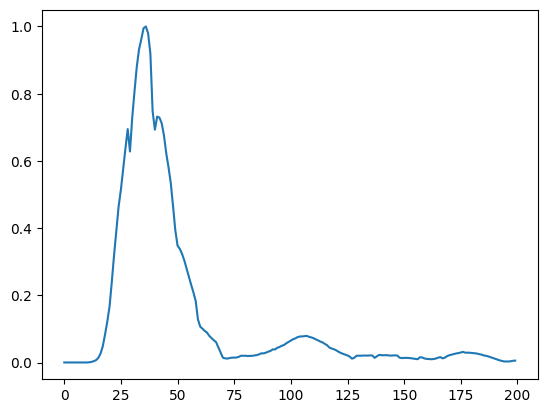

In [9]:
dat = dset.data['processed_voltage_echo_forward_fft'][0]
mag = np.abs(dat)[len(dat)//2:len(dat)//2+200]
plt.plot(mag)

## FFT visualization and scipy fitter

### real morlet only

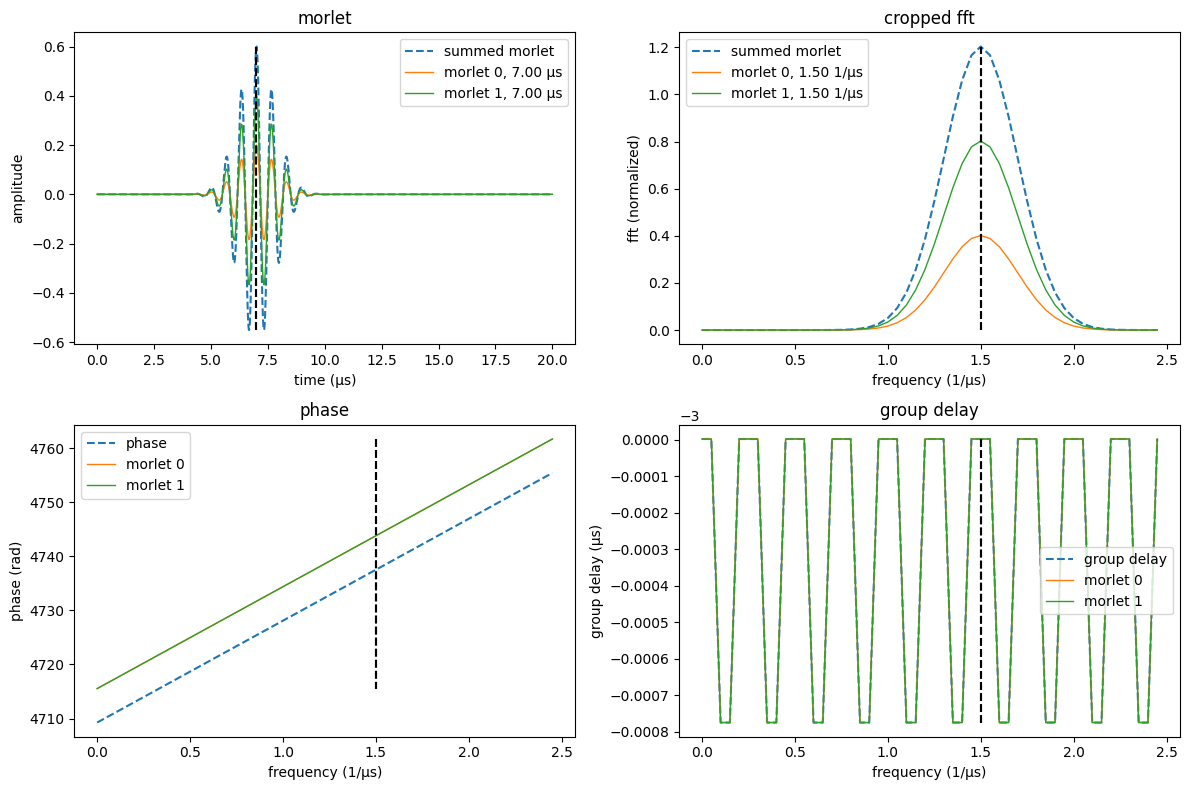

In [32]:
import torch
from models.morlet_fitter import morlet_1D_fitters_real

freq_crop = [dset.spec_len//2, dset.spec_len//2 + 50]
parameters = torch.tensor([[
                            [0.2,  3500, 400, 3.0e-03],
                            [0.4, 3500, 400, 3.0e-03],
                            # [0.05, 3600, 400, 3.0e-03],
                            # [0.1,  4000, 100, 4e-03],
                            # [0.005, 4100, 500, 5e-03],
                           ]])
param_labels = ['a', 'mu', 'sigma', 'f']
fitter = morlet_1D_fitters_real(limits=[1, dset.spec_len, dset.spec_len / 5, 0.05])
t    = np.arange(0, dset.spec_len * dset.dt, dset.dt)
freq = np.fft.fftshift(np.fft.fftfreq(dset.spec_len, dset.dt))

test_morlet = fitter.generate_fit(parameters, dset.spec_len)
fft_morlet = np.array([np.fft.fftshift(np.fft.fft(morlet)) for morlet in test_morlet[0]])
fft_morlet_mag = np.abs(fft_morlet)/freq.max()
morlet_phase = np.array([np.unwrap(np.angle(fft_morlet_i), period = np.pi) for fft_morlet_i in fft_morlet])
morlet_group_delay = np.array([-np.gradient(morlet_phase_i, freq)/2/np.pi for morlet_phase_i in morlet_phase])

summed_morlet = test_morlet[0].sum(axis=0).numpy()
fft_summed_morlet = np.fft.fftshift(np.fft.fft(summed_morlet))
fft_summed_morlet_mag = np.abs(fft_summed_morlet)/freq.max()
summed_morlet_phase = np.unwrap(np.angle(fft_summed_morlet), period = np.pi)
summed_morlet_group_delay = -np.gradient(summed_morlet_phase, freq)/2/np.pi

fig, ax = plt.subplots(2,2, figsize=(12, 8))
ax = ax.flatten()

ax[0].set_title('morlet')
ax[0].set_xlabel('time (μs)')
ax[0].set_ylabel('amplitude')
ax[0].plot(t, summed_morlet, label='summed morlet', linestyle='--')
for i in range( len(test_morlet[0]) ):
    ax[0].plot(t, test_morlet[0][i], label=f'morlet {i}, {parameters[0][i][1]*dset.dt:.2f} μs', linewidth=1)
    ax[0].vlines( t[ parameters[0][i][1].int() ], summed_morlet.min(), summed_morlet.max(), color='black', linestyle='--')
ax[0].legend()


ax[1].set_title('cropped fft')
ax[1].set_xlabel('frequency (1/μs)')
ax[1].set_ylabel('fft (normalized)')
ax[1].plot(freq[freq_crop[0]:freq_crop[1]], fft_summed_morlet_mag[freq_crop[0]:freq_crop[1]], label='summed morlet', linestyle='--')
for i in range(len(test_morlet[0])):
    ax[1].plot(freq[freq_crop[0]:freq_crop[1]], fft_morlet_mag[i, freq_crop[0]:freq_crop[1]], label=f'morlet {i}, {parameters[0][i][3]/dset.dt:.2f} 1/μs', linewidth=1)
    ax[1].vlines(parameters[0][i][3]/dset.dt, fft_summed_morlet_mag.min(), fft_summed_morlet_mag.max(), color='black', linestyle='--')
    # ax[1].vlines(-parameters[0][i][3]/dset.dt, fft_summed_morlet_mag.min(), fft_summed_morlet_mag.max(), color='black', linestyle='--')
ax[1].legend()

ax[2].set_title('phase')
ax[2].set_xlabel('frequency (1/μs)')
ax[2].set_ylabel('phase (rad)')
ax[2].plot(freq[freq_crop[0]:freq_crop[1]], summed_morlet_phase[freq_crop[0]:freq_crop[1]], label='phase', linestyle='--')
for i in range(len(test_morlet[0])):
    ax[2].plot(freq[freq_crop[0]:freq_crop[1]], morlet_phase[i, freq_crop[0]:freq_crop[1]], label=f'morlet {i}', linewidth=1)
    ax[2].vlines(parameters[0][i][3]/dset.dt, 
                 morlet_phase[:, freq_crop[0]:freq_crop[1]].max(), morlet_phase[:, freq_crop[0]:freq_crop[1]].min(), 
                 color='black', linestyle='--')
    # ax[2].vlines(-parameters[0][i][3]/dset.dt, 
    #              morlet_phase[:, freq_crop[0]:freq_crop[1]].max(), morlet_phase[:, freq_crop[0]:freq_crop[1]].min(), 
    #              color='black', linestyle='--')
ax[2].legend()


ax[3].set_title('group delay')
ax[3].set_xlabel('frequency (1/μs)')
ax[3].set_ylabel('group delay (μs)')
ax[3].plot(freq[freq_crop[0]:freq_crop[1]], summed_morlet_group_delay[freq_crop[0]:freq_crop[1]], label='group delay', linestyle='--')
for i in range(len(test_morlet[0])):
    ax[3].plot(freq[freq_crop[0]:freq_crop[1]], morlet_group_delay[i, freq_crop[0]:freq_crop[1]], label=f'morlet {i}', linewidth=1)
    ax[3].vlines(parameters[0][i][3]/dset.dt, 
                 morlet_group_delay[:, freq_crop[0]:freq_crop[1]].min(), morlet_group_delay[:, freq_crop[0]:freq_crop[1]].max(), 
                 color='black', linestyle='--')
    # ax[3].vlines(-parameters[0][i][3]/dset.dt, 
    #              morlet_group_delay[:, freq_crop[0]:freq_crop[1]].min(), morlet_group_delay[:, freq_crop[0]:freq_crop[1]].max(), 
    #              color='black', linestyle='--')
ax[3].legend()

test = parameters[0][0]-parameters[0][1]
inds = np.where(test<0)[0]

# plt.suptitle(f'{param_labels[inds[0]]}: {[p.item() for p in parameters[0,:,inds[0]]]}')
plt.tight_layout()


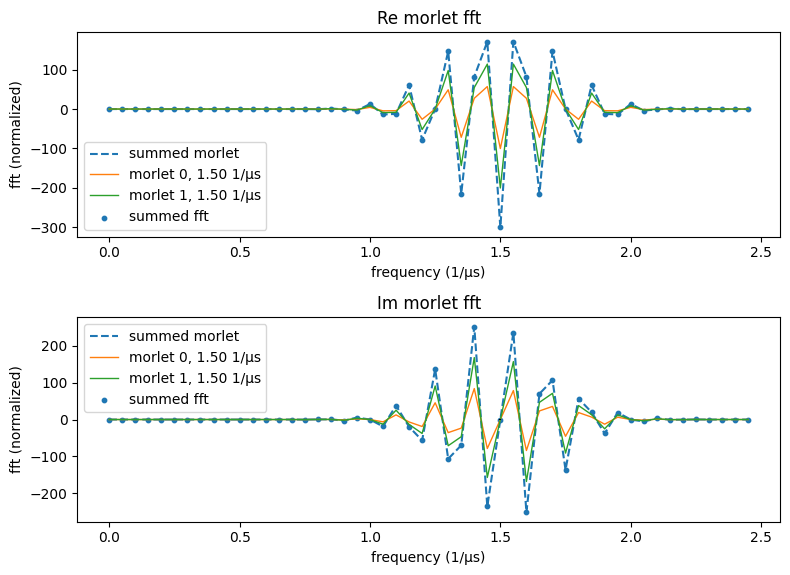

In [33]:
fig, ax = plt.subplots(2, figsize=(8, 6))

ax[0].set_title('Re morlet fft')
ax[0].set_xlabel('frequency (1/μs)')
ax[0].set_ylabel('fft (normalized)')
ax[0].plot(freq[freq_crop[0]:freq_crop[1]], 
           np.real(fft_summed_morlet[freq_crop[0]:freq_crop[1]]), 
           label='summed morlet', linestyle='--')
for i in range(len(test_morlet[0])):
    ax[0].plot(freq[freq_crop[0]:freq_crop[1]], 
               np.real(fft_morlet[i, freq_crop[0]:freq_crop[1]]), 
               label=f'morlet {i}, {parameters[0][i][3]/dset.dt:.2f} 1/μs', linewidth=1)
    ax[0].vlines(parameters[0][i][3]/dset.dt, 
                 fft_summed_morlet_mag.min(), fft_summed_morlet_mag.max(), 
                 color='black', linestyle='--')
ax[0].scatter(freq[freq_crop[0]:freq_crop[1]], 
           np.real(fft_morlet[:, freq_crop[0]:freq_crop[1]]).sum(axis=0), 
           label='summed fft', s=10)
ax[0].legend()

ax[1].set_title('Im morlet fft')
ax[1].set_xlabel('frequency (1/μs)')
ax[1].set_ylabel('fft (normalized)')
ax[1].plot(freq[freq_crop[0]:freq_crop[1]], 
           np.imag(fft_summed_morlet[freq_crop[0]:freq_crop[1]]), 
           label='summed morlet', linestyle='--')
for i in range(len(test_morlet[0])):
    ax[1].plot(freq[freq_crop[0]:freq_crop[1]], 
               np.imag(fft_morlet[i, freq_crop[0]:freq_crop[1]]), 
               label=f'morlet {i}, {parameters[0][i][3]/dset.dt:.2f} 1/μs', linewidth=1)
    ax[1].vlines(parameters[0][i][3]/dset.dt, 
                 fft_summed_morlet_mag.min(), fft_summed_morlet_mag.max(), 
                 color='black', linestyle='--')
ax[1].scatter(freq[freq_crop[0]:freq_crop[1]], 
           np.imag(fft_morlet[:, freq_crop[0]:freq_crop[1]]).sum(axis=0), 
           label='summed fft', s=10)
ax[1].legend()

plt.suptitle('') 
plt.tight_layout()

In [34]:
sigmas = parameters[0,:,3]

ind = np.where(np.isclose(freq, sigmas[0]/dset.dt, atol=1e-6))[0][0]

In [35]:
ind

np.int64(5030)

In [123]:
print(np.isclose(np.real(fft_summed_morlet)[ind:ind+20], np.real(fft_summed_morlet)[ind:ind-20:-1], 
           atol=1e-6).all() )
print(np.isclose(np.imag(fft_summed_morlet)[ind:ind+20], -np.imag(fft_summed_morlet)[ind:ind-20:-1], 
           atol=1e-6).all())

print(np.isclose(np.real(fft_morlet[:,ind:ind+20]).sum(axis=0), np.real(fft_summed_morlet)[ind:ind-20:-1], 
           atol=1e-6).all())
print(np.isclose(np.imag(fft_morlet[:,ind:ind+20]).sum(axis=0), np.imag(fft_summed_morlet)[ind:ind-20:-1], 
           atol=1e-6).all())

print(np.isclose(np.real(fft_morlet[:,ind:ind+20]).sum(axis=0), np.real(fft_summed_morlet)[ind:ind-20:-1], 
           atol=1e-6).all())
print(np.isclose(np.imag(fft_morlet[:,ind:ind+20]).sum(axis=0), np.imag(fft_summed_morlet)[ind:ind-20:-1], 
           atol=1e-6).all())


True
True
True
False
True
False


In [ ]:
np.real(fft_morlet[:,ind:ind+20])
np.imag(fft_morlet[:,ind:ind+20])
np.real(fft_morlet[:,ind:ind+20]).sum(axis=0)
np.imag(fft_morlet[:,ind]).sum(axis=0)

### with imaginary component

/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


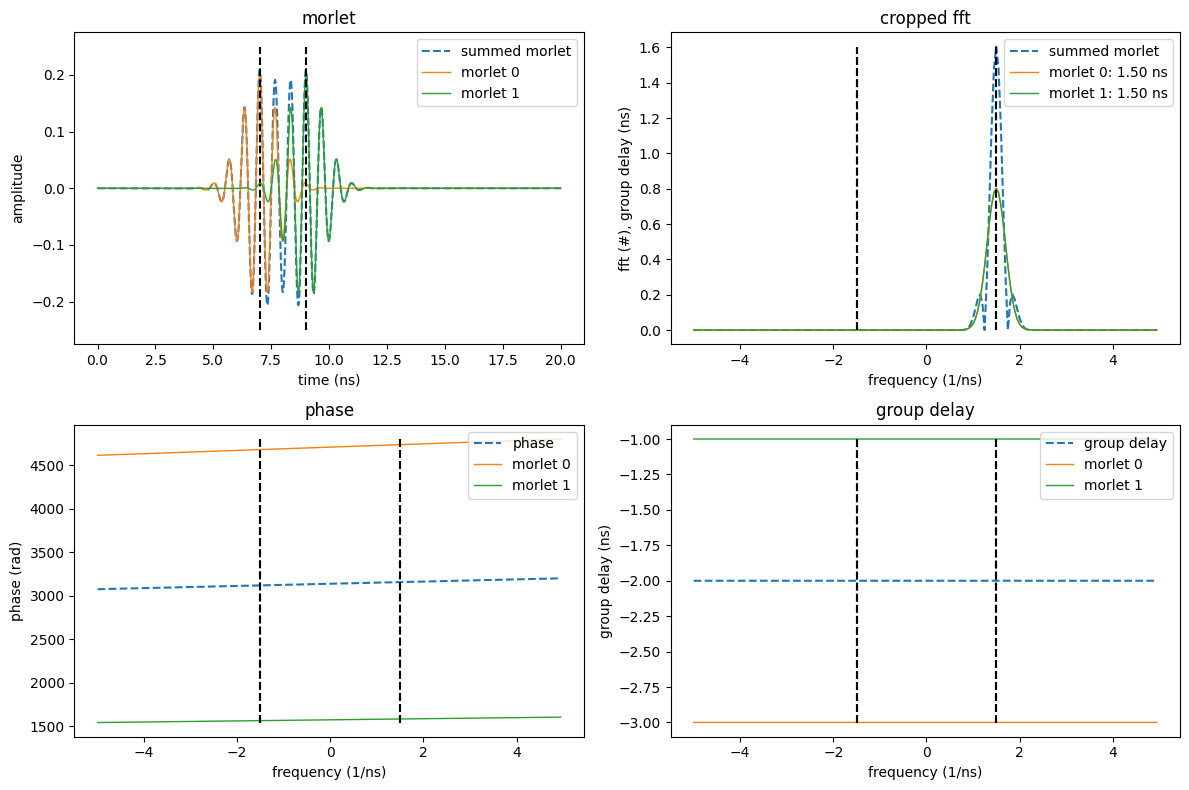

In [55]:
import torch
from models.morlet_fitter_frequency import morlet_1D_fitters_complex

freq_crop = [dset.spec_len//2 - 100, dset.spec_len//2 + 100]
parameters = torch.tensor([[
                            [0.2,  3500, 400, 3.0e-03],
                            [0.2, 4500, 400, 3.0e-03],
                            # [0.05, 3600, 400, 3.0e-03],
                            # [0.1,  4000, 100, 4e-03],
                            # [0.005, 4100, 500, 5e-03],
                           ]])
fitter = morlet_1D_fitters_complex(limits=[1, dset.spec_len, dset.spec_len / 5, 0.05]) # check complex eqn
t    = np.arange(0, dset.spec_len * dset.dt, dset.dt)
freq = np.fft.fftshift(np.fft.fftfreq(dset.spec_len, dset.dt))

test_morlet = fitter.generate_fit_(parameters, dset.spec_len)
fft_morlet = np.array([np.fft.fftshift(np.fft.fft(morlet)) for morlet in test_morlet[0]])
fft_morlet_mag = np.abs(fft_morlet)/freq.max()
morlet_phase = np.array([np.unwrap(np.angle(fft_morlet_i), period = np.pi) for fft_morlet_i in fft_morlet])
morlet_group_delay = np.array([-np.gradient(morlet_phase_i, freq)/2/np.pi for morlet_phase_i in morlet_phase])

summed_morlet = test_morlet[0].sum(axis=0).numpy()
fft_summed_morlet = np.fft.fftshift(np.fft.fft(summed_morlet))
fft_summed_morlet_mag = np.abs(fft_summed_morlet)/freq.max()
summed_morlet_phase = np.unwrap(np.angle(fft_summed_morlet), period = np.pi)
summed_morlet_group_delay = -np.gradient(summed_morlet_phase, freq)/2/np.pi

fig, ax = plt.subplots(2,2, figsize=(12, 8))
ax = ax.flatten()

ax[0].set_title('morlet')
ax[0].set_xlabel('time (ns)')
ax[0].set_ylabel('amplitude')
ax[0].plot(t, summed_morlet, label='summed morlet', linestyle='--')
for i in range( len(test_morlet[0]) ):
    ax[0].plot(t, test_morlet[0][i], label=f'morlet {i}', linewidth=1)
    ax[0].vlines( t[ parameters[0][i][1].int() ], -0.25, 0.25, color='black', linestyle='--')
ax[0].legend()


ax[1].set_title('cropped fft')
ax[1].set_xlabel('frequency (1/ns)')
ax[1].set_ylabel('fft (#), group delay (ns)')
ax[1].plot(freq[freq_crop[0]:freq_crop[1]], fft_summed_morlet_mag[freq_crop[0]:freq_crop[1]], label='summed morlet', linestyle='--')
for i in range(len(test_morlet[0])):
    ax[1].plot(freq[freq_crop[0]:freq_crop[1]], fft_morlet_mag[i, freq_crop[0]:freq_crop[1]], label=f'morlet {i}: {parameters[0][i][3]/dset.dt:.2f} ns', linewidth=1)
    ax[1].vlines(parameters[0][i][3]/dset.dt, 0, fft_summed_morlet_mag.max(), color='black', linestyle='--')
    ax[1].vlines(-parameters[0][i][3]/dset.dt, 0, fft_summed_morlet_mag.max(), color='black', linestyle='--')
ax[1].legend()

ax[2].set_title('phase')
ax[2].set_xlabel('frequency (1/ns)')
ax[2].set_ylabel('phase (rad)')
ax[2].plot(freq[freq_crop[0]:freq_crop[1]], summed_morlet_phase[freq_crop[0]:freq_crop[1]], label='phase', linestyle='--')
for i in range(len(test_morlet[0])):
    ax[2].plot(freq[freq_crop[0]:freq_crop[1]], morlet_phase[i, freq_crop[0]:freq_crop[1]], label=f'morlet {i}', linewidth=1)
    ax[2].vlines(parameters[0][i][3]/dset.dt, 
                 morlet_phase[:, freq_crop[0]:freq_crop[1]].max(), morlet_phase[:, freq_crop[0]:freq_crop[1]].min(), 
                 color='black', linestyle='--')
    ax[2].vlines(-parameters[0][i][3]/dset.dt, 
                 morlet_phase[:, freq_crop[0]:freq_crop[1]].max(), morlet_phase[:, freq_crop[0]:freq_crop[1]].min(), 
                 color='black', linestyle='--')
ax[2].legend()


ax[3].set_title('group delay')
ax[3].set_xlabel('frequency (1/ns)')
ax[3].set_ylabel('group delay (ns)')
ax[3].plot(freq[freq_crop[0]:freq_crop[1]], summed_morlet_group_delay[freq_crop[0]:freq_crop[1]], label='group delay', linestyle='--')
for i in range(len(test_morlet[0])):
    ax[3].plot(freq[freq_crop[0]:freq_crop[1]], morlet_group_delay[i, freq_crop[0]:freq_crop[1]], label=f'morlet {i}', linewidth=1)
    ax[3].vlines(parameters[0][i][3]/dset.dt, 
                 morlet_group_delay[:, freq_crop[0]:freq_crop[1]].min(), morlet_group_delay[:, freq_crop[0]:freq_crop[1]].max(), 
                 color='black', linestyle='--')
    ax[3].vlines(-parameters[0][i][3]/dset.dt, 
                 morlet_group_delay[:, freq_crop[0]:freq_crop[1]].min(), morlet_group_delay[:, freq_crop[0]:freq_crop[1]].max(), 
                 color='black', linestyle='--')
ax[3].legend()

plt.suptitle()
plt.tight_layout()

In [195]:
t[3500], t[4500]

(np.float64(7.000700070007), np.float64(9.000900090009))

In [142]:
1/parameters[0][i][3]

tensor(333.3333)

In [101]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.interpolate import interp1d
from models.morlet_fitter import morlet_1D_fitters_real
import torch

data_crop = 2**13
freq_crop = [data_crop//2 - 100, data_crop//2 + 100]
parameters = torch.tensor([[
                            [0.2,  3500, 350, 3.0e-03],
                            [0.2, 4500, 400, 3.0e-03],
                            # [0.05, 3600, 400, 3.0e-03],
                            # [0.1,  4000, 100, 4e-03],
                            # [0.005, 4100, 500, 5e-03],
                           ]])
fitter = morlet_1D_fitters_real(limits=[1, dset.spec_len, dset.spec_len / 5, 0.05])
t    = np.arange(0, data_crop * dset.dt, dset.dt)
freq = np.fft.fftshift(np.fft.fftfreq(data_crop, dset.dt))

col_titles = ["Morlet", "Summed Morlet", "Echo"]
row_titles = ["amplitude (normalized)", "FFT magnitude", "FFT phase shift", "FFT group delay"]

fig = make_subplots(
    rows=4, cols=3,
    column_titles=col_titles,
    row_titles=row_titles,
    shared_xaxes=False,
    vertical_spacing=0.08,
    horizontal_spacing=0.08,
)

# ── Column 0: individual Morlets ──────────────────────────────────────────────
test_morlet = fitter.generate_fit(parameters, data_crop)
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, morlet in enumerate(test_morlet[0]):
    morlet       = morlet.numpy()
    fft_morlet   = np.fft.fftshift(np.fft.fft(morlet)) / max(freq)
    morlet_phase = np.unwrap(np.angle(fft_morlet))
    name         = f"morlet {i}"
    color        = colors[i]

    fig.add_trace(go.Scatter(x=t, y=morlet, name=name, legendgroup=name, line=dict(color=color)), row=1, col=1)
    fig.add_trace(go.Scatter(x=freq[freq_crop[0]:freq_crop[1]], y=np.abs(fft_morlet[freq_crop[0]:freq_crop[1]]), name=name, legendgroup=name, showlegend=False, line=dict(color=color)), row=2, col=1)
    fig.add_trace(go.Scatter(x=freq[freq_crop[0]:freq_crop[1]], y=morlet_phase[freq_crop[0]:freq_crop[1]], name=name, legendgroup=name, showlegend=False, line=dict(color=color)), row=3, col=1)
    fig.add_trace(go.Scatter(x=freq[freq_crop[0]:freq_crop[1]], y=-np.gradient(morlet_phase, freq)[freq_crop[0]:freq_crop[1]], name=name, legendgroup=name, showlegend=False, line=dict(color=color)), row=4, col=1)

# ── Column 1: summed Morlet ───────────────────────────────────────────────────
summed_morlet = test_morlet[0].sum(axis=0).numpy()
fft_summed    = np.fft.fftshift(np.fft.fft(summed_morlet)) / max(freq)
summed_phase  = np.unwrap(np.angle(fft_summed))

fig.add_trace(go.Scatter(x=t, y=summed_morlet, name="summed", showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=freq[freq_crop[0]:freq_crop[1]], y=np.abs(fft_summed[freq_crop[0]:freq_crop[1]]), name="summed", showlegend=False), row=2, col=2)
fig.add_trace(go.Scatter(x=freq[freq_crop[0]:freq_crop[1]], y=summed_phase[freq_crop[0]:freq_crop[1]], name="summed", showlegend=False), row=3, col=2)
fig.add_trace(go.Scatter(x=freq[freq_crop[0]:freq_crop[1]], y=-np.gradient(summed_phase, freq)[freq_crop[0]:freq_crop[1]], name="summed", showlegend=False), row=4, col=2)

# ── Column 2: echo ────────────────────────────────────────────────────────────
echo       = dset.data["processed_voltage_echo_forward"][0][:data_crop]
fft_echo   = np.fft.fftshift(np.fft.fft(echo)) / max(freq)
echo_phase = np.unwrap(np.angle(fft_echo))

fig.add_trace(go.Scatter(x=t, y=echo, name="echo", showlegend=False), row=1, col=3)
fig.add_trace(go.Scatter(x=freq[freq_crop[0]:freq_crop[1]], y=np.abs(fft_echo[freq_crop[0]:freq_crop[1]]), name="echo", showlegend=False), row=2, col=3)
fig.add_trace(go.Scatter(x=freq[freq_crop[0]:freq_crop[1]], y=echo_phase[freq_crop[0]:freq_crop[1]], name="echo", showlegend=False), row=3, col=3)
fig.add_trace(go.Scatter(x=freq[freq_crop[0]:freq_crop[1]], y=-np.gradient(echo_phase, freq)[freq_crop[0]:freq_crop[1]], name="echo", showlegend=False), row=4, col=3)

# ── Axis labels ───────────────────────────────────────────────────────────────
for col in range(1, 4):
    fig.update_xaxes(title_text="time (ns)", row=1, col=col)
    for row in range(2, 5):
        fig.update_xaxes(title_text="frequency (1/ns)", row=row, col=col)

fig.update_layout(height=1000, width=1300, title_text="Morlet / Summed Morlet / Echo")
fig.show()

### fit echo with scipy

In [59]:
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import pandas as pd

# finding the phase shifts
f = freq[len(freq)//2:len(freq)//2+100]
mag = np.abs(fft_echo[len(freq)//2:len(freq)//2+100])
angles = np.unwrap(np.angle(fft_echo[len(freq)//2:len(freq)//2+100]))

def gaussian_5(x, 
               a1, a2, a3, a4, a5, 
               mu1, mu2, mu3, mu4, mu5, 
               sigma1, sigma2, sigma3, sigma4, sigma5):
    return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) + \
           a2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2)) + \
           a3 * np.exp(-(x - mu3)**2 / (2 * sigma3**2)) + \
           a4 * np.exp(-(x - mu4)**2 / (2 * sigma4**2)) + \
           a5 * np.exp(-(x - mu5)**2 / (2 * sigma5**2))
           
def gaussian(x, a1, mu1, sigma1): return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) 

def morlet_function(t, a, mu, sigma, f): return a * np.exp(-(t - mu)**2 / (2 * sigma**2)) * np.exp(1j * 2 * np.pi * f * (t-mu))

## fit parameters
# try interpolating next?
popt, _ = curve_fit( gaussian_5, f, mag,
                    bounds=([0,0,0,0,0,
                             0,0,0,0,0,
                             0,0,0,0,0], 
                            [mag.max(),mag.max(),mag.max(),mag.max(),mag.max(),
                             f[-1],f[-1],f[-1],f[-1],f[-1],
                             100,100,100,100,100]),
                    ftol=1e-12, xtol=1e-12, gtol=1e-12, max_nfev=10000)

parameters = pd.DataFrame({'a_f':popt[:5], 'mu_f':popt[5:10], 'sigma_f':popt[10:] })

## fing group delays
means_f = popt[5:10]
group_delay = -np.gradient(angles, f)
interp = interp1d(f, group_delay)
g_delays = interp(means_f)

## calculate in time domain
parameters['mu_t'] = g_delays/2/np.pi
parameters['sigma_t'] = 1/2/np.pi/parameters['sigma_f']
parameters['a_t'] = parameters['a_f']/(2*np.pi*parameters['sigma_t']**2)**0.5
parameters = parameters.loc[:, ['a_f', 'mu_f', 'sigma_f', 'a_t', 'mu_t', 'sigma_t']]

## make morlet with given parameters
t = np.arange(0, data_crop*dset.dt, dset.dt)
morlet = np.array([morlet_function(t, 
                                   parameters['a_t'][i], 
                                   parameters['mu_t'][i], 
                                   parameters['sigma_t'][i], 
                                   parameters['mu_f'][i]) for i in range(len(parameters))])

parameters

,a_f,mu_f,sigma_f,a_t,mu_t,sigma_t
0,0.038183,2.382664,0.245132,0.023462,7.207593,0.649262
1,0.166753,1.570790,0.192551,0.080484,7.347586,0.826561
2,0.137888,1.220523,0.169126,0.058455,7.130000,0.941046
3,0.060661,1.871160,0.309577,0.047072,7.857673,0.514104
4,0.008653,3.353221,1.186938,0.025745,6.921396,0.134089


/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


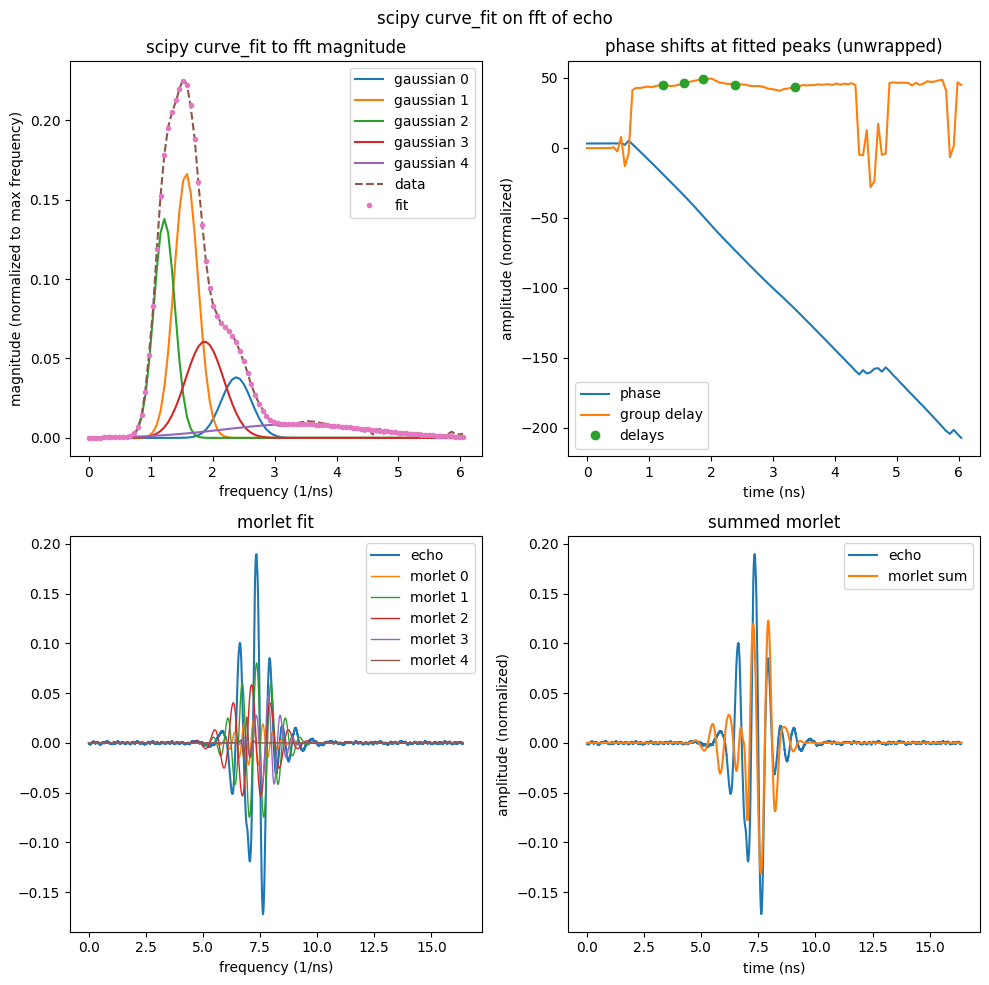

In [60]:
fig, axs = plt.subplots(2,2, figsize=(10, 10))

fig.suptitle('scipy curve_fit on fft of echo')

axs[0,0].set_title('scipy curve_fit to fft magnitude')
for i in range(5):
    axs[0,0].plot(freq[len(freq)//2:len(freq)//2+100], 
             gaussian(freq[len(freq)//2:len(freq)//2+100], *popt[[i, i+5, i+10]]), 
             label=f'gaussian {i}')
axs[0,0].plot(f, mag, '--', label='data')
axs[0,0].plot(f, gaussian_5(f, *popt), '.', label='fit')
axs[0,0].legend()
axs[0,0].set_ylabel('magnitude (normalized to max frequency)')

axs[0,1].set_title('phase shifts at fitted peaks (unwrapped)')
axs[0,1].plot(f, angles, label='phase')
axs[0,1].plot(f, group_delay, label='group delay')
axs[0,1].plot(means_f, g_delays, 'o', label='delays')
axs[0,1].legend()
axs[0,1].set_ylabel('phase (rad), group delay (ns)')

axs[1,0].set_title('morlet fit')
axs[1,0].plot(t, dset.data['processed_voltage_echo_forward'][1034][:data_crop], label='echo')
for i in range(len(parameters['a_t'])): 
    axs[1,0].plot(t, morlet[i], linewidth=1, label=f'morlet {i}') 
axs[1,0].legend()

axs[1,1].set_title('summed morlet')
axs[1,1].plot(t, echo, label='echo')
axs[1,1].plot(t, morlet.sum(axis=0), label='morlet sum')
axs[1,1].legend()

for i in range(2):
    axs[i,0].set_xlabel('frequency (1/ns)')
    axs[i,1].set_xlabel('time (ns)')
    axs[i,1].set_ylabel('amplitude (normalized)')

fig.tight_layout()

### fit toy

In [504]:
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import pandas as pd

# finding the phase shifts
f = freq[len(freq)//2:len(freq)//2+100]
mag = np.abs(fft_summed_morlet[len(freq)//2:len(freq)//2+100])
angles = np.unwrap(np.angle(fft_summed_morlet[len(freq)//2:len(freq)//2+100]))

def gaussian_5(x, 
               a1, a2, a3, a4, a5, 
               mu1, mu2, mu3, mu4, mu5, 
               sigma1, sigma2, sigma3, sigma4, sigma5):
    return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) + \
           a2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2)) + \
           a3 * np.exp(-(x - mu3)**2 / (2 * sigma3**2)) + \
           a4 * np.exp(-(x - mu4)**2 / (2 * sigma4**2)) + \
           a5 * np.exp(-(x - mu5)**2 / (2 * sigma5**2))
           
def gaussian(x, a1, mu1, sigma1): return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) 

def morlet_function(t, a, mu, sigma, f): return a * np.exp(-(t - mu)**2 / (2 * sigma**2)) * np.exp(1j * 2 * np.pi * f * (t-mu))

## fit parameters
# try interpolating next?
popt, _ = curve_fit( gaussian_5, f, mag,
                    bounds=([0,0,0,0,0,
                             0,0,0,0,0,
                             0,0,0,0,0], 
                            [mag.max(),mag.max(),mag.max(),mag.max(),mag.max(),
                             f[-1],f[-1],f[-1],f[-1],f[-1],
                             100,100,100,100,100]),
                    ftol=1e-12, xtol=1e-12, gtol=1e-12, max_nfev=10000)

parameters = pd.DataFrame({'a_f':popt[:5], 'mu_f':popt[5:10], 'sigma_f':popt[10:] })

## find group delays
means_f = popt[5:10]
group_delay = -np.gradient(angles, f)
interp = interp1d(f, group_delay)
g_delays = interp(means_f)

## calculate in time domain
parameters['mu_t'] = g_delays/2/np.pi
parameters['sigma_t'] = 1/2/np.pi/parameters['sigma_f']
parameters['a_t'] = parameters['a_f']/(2*np.pi*parameters['sigma_t']**2)**0.5
parameters = parameters.loc[:, ['a_f', 'mu_f', 'sigma_f', 'a_t', 'mu_t', 'sigma_t']]

## make morlet with given parameters
t = np.arange(0, data_crop*dset.dt, dset.dt)
morlet = np.array([morlet_function(t, parameters['a_t'][i], parameters['mu_t'][i], parameters['sigma_t'][i], parameters['mu_f'][i]) for i in range(len(parameters))])

parameters

,a_f,mu_f,sigma_f,a_t,mu_t,sigma_t
0,0.273740,1.521753,0.131456,0.090201,7.297635,1.210705
1,0.122280,1.261096,0.166350,0.050988,6.832409,0.956748
2,0.037112,2.017405,0.897164,0.083459,7.631349,0.177398
3,0.013828,2.132985,0.118920,0.004122,7.855013,1.338339
4,0.031469,1.888976,0.099924,0.007882,7.152869,1.592765


/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


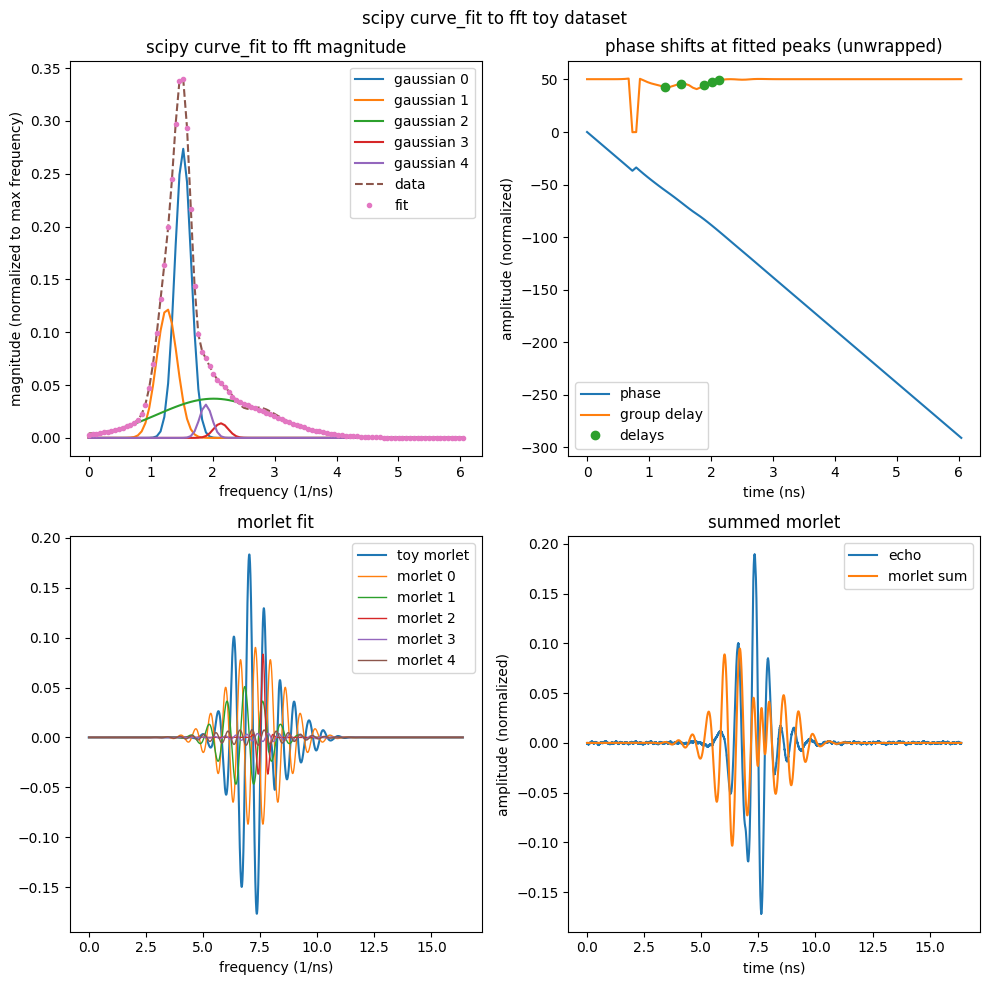

In [505]:
fig, axs = plt.subplots(2,2, figsize=(10, 10))
fig.suptitle('scipy curve_fit to fft toy dataset')

axs[0,0].set_title('scipy curve_fit to fft magnitude')
for i in range(5):
    axs[0,0].plot(freq[len(freq)//2:len(freq)//2+100], 
             gaussian(freq[len(freq)//2:len(freq)//2+100], *popt[[i, i+5, i+10]]), 
             label=f'gaussian {i}')
axs[0,0].plot(f, mag, '--', label='data')
axs[0,0].plot(f, gaussian_5(f, *popt), '.', label='fit')
axs[0,0].legend()
axs[0,0].set_ylabel('magnitude (normalized to max frequency)')


axs[0,1].set_title('phase shifts at fitted peaks (unwrapped)')
axs[0,1].plot(f, angles, label='phase')
axs[0,1].plot(f, group_delay, label='group delay')
axs[0,1].plot(means_f, g_delays, 'o', label='delays')
axs[0,1].legend()
axs[0,1].set_ylabel('phase (rad), group delay (ns)')

axs[1,0].set_title('morlet fit')
axs[1,0].plot(t, summed_morlet, label='toy morlet')
for i in range(len(parameters['a_t'])): 
    axs[1,0].plot(t, morlet[i], linewidth=1, label=f'morlet {i}') 
axs[1,0].legend()

axs[1,1].set_title('summed morlet')
axs[1,1].plot(t, echo, label='echo')
axs[1,1].plot(t, morlet.sum(axis=0), label='morlet sum')
axs[1,1].legend()

for i in range(2):
    axs[i,0].set_xlabel('frequency (1/ns)')
    axs[i,1].set_xlabel('time (ns)')
    axs[i,1].set_ylabel('amplitude (normalized)')

fig.tight_layout()

### fit echo with interpolation

In [66]:
freq

array([-249.975     , -249.91397095, -249.85294189, ...,  249.79191284,
        249.85294189,  249.91397095], shape=(8192,))

In [69]:
freq_

array([-249.975     , -249.94448547, -249.91397095, ...,  249.88345642,
        249.91397095,  249.94448547], shape=(16384,))

In [88]:
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import pandas as pd

# finding the phase shifts
t_ = np.arange(0, data_crop * dset.dt, dset.dt / 2)
t_[-1] = t[-1]
freq_ = np.fft.fftshift(np.fft.fftfreq(n=len(freq)*2, d=dset.dt/2))
f = freq_[len(freq_)//2:len(freq_)//2+200]

echo_ = interp1d(t, echo)(t_)
fft_echo_ = np.fft.fftshift(np.fft.fft(echo_))/max(freq_)
mag_ = np.abs(fft_echo_[len(freq_)//2:len(freq_)//2+200])
angles = np.unwrap(np.angle(fft_echo_[len(freq_)//2:len(freq_)//2+200]))

def gaussian_5(x, a1, a2, a3, a4, a5, 
               mu1, mu2, mu3, mu4, mu5, 
               sigma1, sigma2, sigma3, sigma4, sigma5):
    return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) + \
           a2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2)) + \
           a3 * np.exp(-(x - mu3)**2 / (2 * sigma3**2)) + \
           a4 * np.exp(-(x - mu4)**2 / (2 * sigma4**2)) + \
           a5 * np.exp(-(x - mu5)**2 / (2 * sigma5**2))
           
def gaussian(x, a1, mu1, sigma1): return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) 

def morlet_function(t, a, mu, sigma, f): return a * np.exp(-(t - mu)**2 / (2 * sigma**2)) * np.exp(1j * 2 * np.pi * f * (t-mu))

## fit parameters
# try interpolating next?
popt, _ = curve_fit( gaussian_5, f, mag_,
                    bounds=([0,0,0,0,0,
                             0,0,0,0,0,
                             0,0,0,0,0], 
                            [mag_.max(),mag_.max(),mag_.max(),mag_.max(),mag_.max(),
                             f[-1],f[-1],f[-1],f[-1],f[-1],
                             100,100,100,100,100]),
                    ftol=1e-12, xtol=1e-12, gtol=1e-12, max_nfev=10000)

parameters = pd.DataFrame({'a_f':popt[:5], 'mu_f':popt[5:10], 'sigma_f':popt[10:] })

## fing group delays
means_f = popt[5:10]
group_delay = -np.gradient(angles, f)
interp = interp1d(f, group_delay)
g_delays = interp(means_f)

## calculate in time domain
parameters['mu_t'] = g_delays/2/np.pi
parameters['sigma_t'] = 1/2/np.pi/parameters['sigma_f']
parameters['a_t'] = parameters['a_f']/(2*np.pi*parameters['sigma_t']**2)**0.5
parameters = parameters.loc[:, ['a_f', 'mu_f', 'sigma_f', 'a_t', 'mu_t', 'sigma_t']]

## make morlet with given parameters
morlet = np.array([morlet_function(t_, 
                                   parameters['a_t'][i], 
                                   parameters['mu_t'][i], 
                                   parameters['sigma_t'][i], 
                                   parameters['mu_f'][i]) for i in range(len(parameters))])

parameters

,a_f,mu_f,sigma_f,a_t,mu_t,sigma_t
0,0.135115,1.217161,0.167201,0.056628,7.129299,0.951878
1,0.174348,1.568148,0.196334,0.085803,7.341924,0.810633
2,0.039183,2.378073,0.248102,0.024368,7.210992,0.641490
3,0.008344,3.332912,1.339633,0.028020,6.889883,0.118805
4,0.056067,1.891117,0.296270,0.041638,7.887485,0.537195


/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


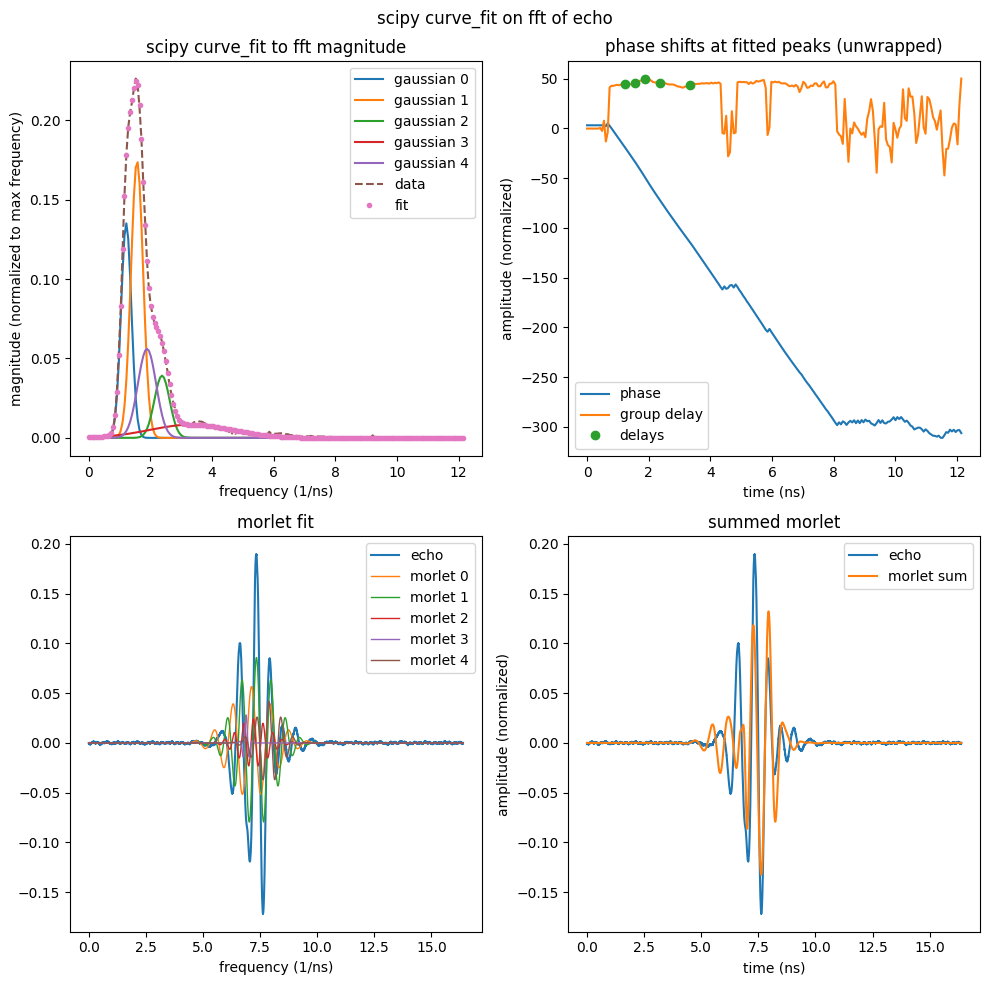

In [89]:
fig, axs = plt.subplots(2,2, figsize=(10, 10))

fig.suptitle('scipy curve_fit on fft of echo')

axs[0,0].set_title('scipy curve_fit to fft magnitude')
for i in range(5):
    axs[0,0].plot(f, 
             gaussian(f, *popt[[i, i+5, i+10]]), 
             label=f'gaussian {i}')
axs[0,0].plot(f, mag_, '--', label='data')
axs[0,0].plot(f, gaussian_5(f, *popt), '.', label='fit')
axs[0,0].legend()
axs[0,0].set_ylabel('magnitude (normalized to max frequency)')

axs[0,1].set_title('phase shifts at fitted peaks (unwrapped)')
axs[0,1].plot(f, angles, label='phase')
axs[0,1].plot(f, group_delay, label='group delay')
axs[0,1].plot(means_f, g_delays, 'o', label='delays')
axs[0,1].legend()
axs[0,1].set_ylabel('phase (rad), group delay (ns)')

axs[1,0].set_title('morlet fit')
axs[1,0].plot(t_, echo_, label='echo')
for i in range(len(parameters['a_t'])): 
    axs[1,0].plot(t_, morlet[i], linewidth=1, label=f'morlet {i}') 
axs[1,0].legend()

axs[1,1].set_title('summed morlet')
axs[1,1].plot(t_, echo_, label='echo')
axs[1,1].plot(t_, morlet.sum(axis=0), label='morlet sum')
axs[1,1].legend()

for i in range(2):
    axs[i,0].set_xlabel('frequency (1/ns)')
    axs[i,1].set_xlabel('time (ns)')
    axs[i,1].set_ylabel('amplitude (normalized)')

fig.tight_layout()

### fit toy with interpolation

In [507]:
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import pandas as pd

# finding the phase shifts
t_ = np.arange(0, data_crop * dset.dt, dset.dt / 2)
t_[-1] = t[-1]
freq_ = np.fft.fftshift(np.fft.fftfreq(len(freq)*2, dset.dt/2))
f = freq_[len(freq_)//2:len(freq_)//2+200]
summed_morlet_ = interp1d(t, summed_morlet)(t_)
fft_summed_morlet_ = np.fft.fftshift(np.fft.fft(summed_morlet_))/max(freq_)
mag_ = np.abs(fft_summed_morlet_[len(freq_)//2:len(freq_)//2+200])
angles = np.unwrap(np.angle(fft_summed_morlet_[len(freq_)//2:len(freq_)//2+200]))

def gaussian_5(x, a1, a2, a3, a4, a5, 
               mu1, mu2, mu3, mu4, mu5, 
               sigma1, sigma2, sigma3, sigma4, sigma5):
    return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) + \
           a2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2)) + \
           a3 * np.exp(-(x - mu3)**2 / (2 * sigma3**2)) + \
           a4 * np.exp(-(x - mu4)**2 / (2 * sigma4**2)) + \
           a5 * np.exp(-(x - mu5)**2 / (2 * sigma5**2))
           
def gaussian(x, a1, mu1, sigma1): return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) 

def morlet_function(t, a, mu, sigma, f): return a * np.exp(-(t - mu)**2 / (2 * sigma**2)) * np.exp(1j * 2 * np.pi * f * (t-mu))

## fit parameters
# try interpolating next?
popt, _ = curve_fit( gaussian_5, f, mag_,
                    bounds=([0,0,0,0,0,
                             0,0,0,0,0,
                             0,0,0,0,0], 
                            [mag_.max(),mag_.max(),mag_.max(),mag_.max(),mag_.max(),
                             f[-1],f[-1],f[-1],f[-1],f[-1],
                             100,100,100,100,100]),
                    ftol=1e-12, xtol=1e-12, gtol=1e-12, max_nfev=10000)

parameters = pd.DataFrame({'a_f':popt[:5], 'mu_f':popt[5:10], 'sigma_f':popt[10:] })

## fing group delays
means_f = popt[5:10]
group_delay = -np.gradient(angles, f)
interp = interp1d(f, group_delay)
g_delays = interp(means_f)

## calculate in time domain
parameters['mu_t'] = g_delays/2/np.pi
parameters['sigma_t'] = 1/2/np.pi/parameters['sigma_f']
parameters['a_t'] = parameters['a_f']/(2*np.pi*parameters['sigma_t']**2)**0.5
parameters = parameters.loc[:, ['a_f', 'mu_f', 'sigma_f', 'a_t', 'mu_t', 'sigma_t']]

## make morlet with given parameters
morlet = np.array([morlet_function(t_, 
                                   parameters['a_t'][i], 
                                   parameters['mu_t'][i], 
                                   parameters['sigma_t'][i], 
                                   parameters['mu_f'][i]) for i in range(len(parameters))])

parameters

,a_f,mu_f,sigma_f,a_t,mu_t,sigma_t
0,0.042112,1.745142,0.262957,0.027757,6.583567,0.605252
1,0.037247,2.017843,0.893533,0.083423,7.632271,0.178119
2,0.207763,1.505957,0.111369,0.057999,7.272049,1.429079
3,0.034618,1.624129,0.072608,0.006301,7.158712,2.191969
4,0.136804,1.294350,0.178065,0.061062,6.806838,0.893801


/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


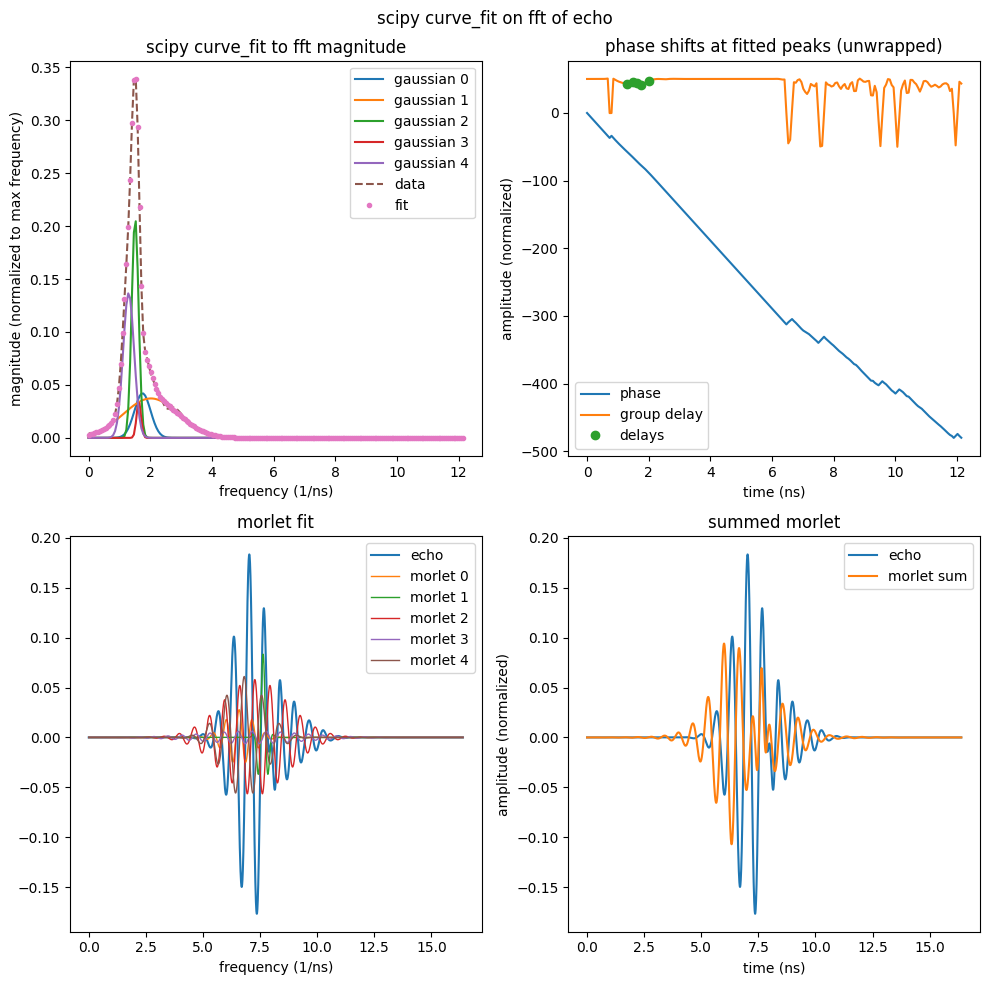

In [508]:
fig, axs = plt.subplots(2,2, figsize=(10, 10))

fig.suptitle('scipy curve_fit on fft of echo')

axs[0,0].set_title('scipy curve_fit to fft magnitude')
for i in range(5):
    axs[0,0].plot(freq[len(freq)//2:len(freq)//2+200], 
             gaussian(freq[len(freq)//2:len(freq)//2+200], *popt[[i, i+5, i+10]]), 
             label=f'gaussian {i}')
axs[0,0].plot(f, mag_, '--', label='data')
axs[0,0].plot(f, gaussian_5(f, *popt), '.', label='fit')
axs[0,0].legend()
axs[0,0].set_ylabel('magnitude (normalized to max frequency)')

axs[0,1].set_title('phase shifts at fitted peaks (unwrapped)')
axs[0,1].plot(f, angles, label='phase')
axs[0,1].plot(f, group_delay, label='group delay')
axs[0,1].plot(means_f, g_delays, 'o', label='delays')
axs[0,1].legend()
axs[0,1].set_ylabel('phase (rad), group delay (ns)')

axs[1,0].set_title('morlet fit')
axs[1,0].plot(t_, summed_morlet_, label='echo')
for i in range(len(parameters['a_t'])): 
    axs[1,0].plot(t_, morlet[i], linewidth=1, label=f'morlet {i}') 
axs[1,0].legend()

axs[1,1].set_title('summed morlet')
axs[1,1].plot(t_, summed_morlet_, label='echo')
axs[1,1].plot(t_, morlet.sum(axis=0), label='morlet sum')
axs[1,1].legend()

for i in range(2):
    axs[i,0].set_xlabel('frequency (1/ns)')
    axs[i,1].set_xlabel('time (ns)')
    axs[i,1].set_ylabel('amplitude (normalized)')

fig.tight_layout()

## torch spectogram

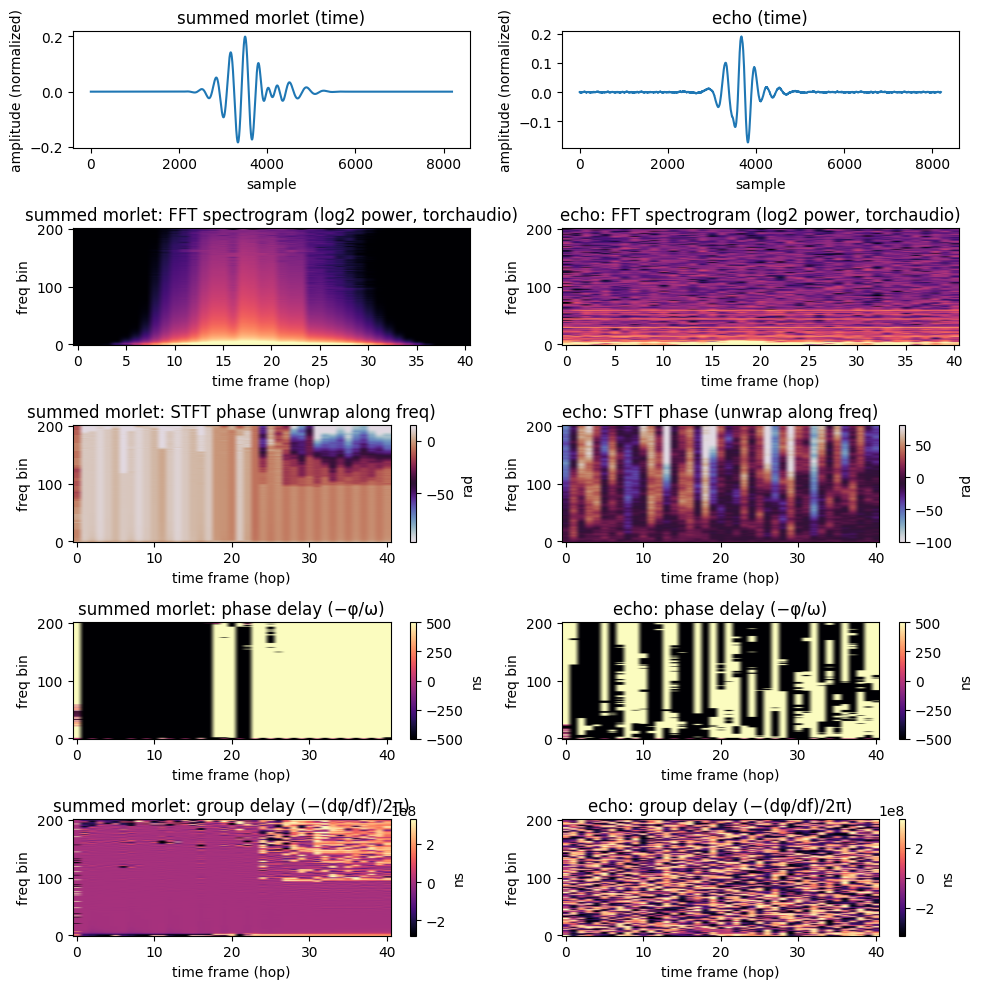

In [41]:
import torchaudio
import matplotlib.pyplot as plt
import torch
import numpy as np
from models.morlet_fitter import morlet_1D_fitters_real

i = 1034
data_crop = 2**13
fig, axs = plt.subplots(5, 2, figsize=(10, 10))

sample_rate = float(1.0 / dset.dt)
# Same window/hop as default torchaudio Spectrogram (n_fft=400, hop=win_length/2=200)
N_FFT, HOP = 400, 200
# Match torchaudio: power=2.0, same STFT; use for log2 mag image like the small torchaudio example
spec_pow = torchaudio.transforms.Spectrogram(
    n_fft=N_FFT, hop_length=HOP, power=2.0, center=True
)
win = torch.hann_window(N_FFT)
freqs = np.fft.rfftfreq(N_FFT, d=1.0 / sample_rate)
omega = 2.0 * np.pi * freqs
omega[0] = omega[1]  # avoid DC divide


def to_torch1d(wave_1d):
    return torch.as_tensor(wave_1d, dtype=torch.float32).reshape(-1)


def stft_complex(wave_1d):
    w = to_torch1d(wave_1d)
    S = torch.stft(
        w,
        n_fft=N_FFT,
        hop_length=HOP,
        win_length=N_FFT,
        window=win.to(w.device),
        center=True,
        return_complex=True,
    )
    return S.cpu().numpy()


def stft_ims(wave_1d):
    S = stft_complex(wave_1d)
    phase = np.unwrap(np.angle(S), axis=0)
    t_delay_ns = -phase / omega[:, None] * 1e9
    dphi_df = np.apply_along_axis(
        lambda p: np.gradient(p, freqs), 0, phase
    )  # slice along rows = phase vs freq; axis 1 would be time, wrong for len(freqs)
    g_delay_ns = -(dphi_df) / (2.0 * np.pi) * 1e9
    return phase, t_delay_ns, g_delay_ns


def imshow2d(X, ax, title, cbar_label=None, cmap="magma", robust=True, vmin=None, vmax=None):
    if vmin is None and vmax is None and robust:
        vmin, vmax = np.nanpercentile(X, 1), np.nanpercentile(X, 99)
    m = ax.imshow(X, aspect="auto", origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    if cbar_label is not None:
        plt.colorbar(m, ax=ax, label=cbar_label)


def spec_log2(ax, w_1d, title):
    w = to_torch1d(w_1d).unsqueeze(0)
    P = spec_pow(w).squeeze(0).numpy()
    imshow2d(np.log2(P + 1e-20), ax, title, cmap="magma")


def plot_column(wave, col, title_tag):
    y = np.asarray(wave, dtype=np.float32)
    phase, t_delay, g_delay = stft_ims(wave)
    axs[0, col].set_title(f"{title_tag} (time)")
    axs[0, col].plot(y)
    axs[0, col].set_xlabel("sample")
    axs[0, col].set_ylabel("amplitude (normalized)")

    spec_log2(
        axs[1, col], wave, f"{title_tag}: FFT spectrogram (log2 power, torchaudio)"
    )

    imshow2d(phase, axs[2, col], f"{title_tag}: STFT phase (unwrap along freq)", cmap="twilight", cbar_label="rad")
    imshow2d(
        t_delay,
        axs[3, col],
        f"{title_tag}: phase delay (−φ/ω)",
        cbar_label="ns",
        robust=False,
        vmin=-500,
        vmax=500,
    )  # match original 1D phase-delay row (ns)
    imshow2d(
        g_delay, axs[4, col], f"{title_tag}: group delay (−(dφ/df)/2π)", cbar_label="ns"
    )

    for r in (1, 2, 3, 4):
        axs[r, col].set_xlabel("time frame (hop)")
    axs[1, col].set_ylabel("freq bin")
    for r in (2, 3, 4):
        axs[r, col].set_ylabel("freq bin")


morlet_class = morlet_1D_fitters_real(
    limits=[1, dset.spec_len, dset.spec_len / 5, 0.05]
)
pars = torch.tensor(
    [
        [
            [0.2, 3500, 400, 3.0e-03],
            [0.025, 4500, 400, 2.5e-03],
            [0.1, 4000, 200, 3.5e-03],
        ],
    ]
)

test_ = morlet_class.generate_fit(pars, data_crop)
test_morlet_sum = test_.sum(axis=1)[0].numpy()
test_echo = dset.data["processed_voltage_echo_forward"][i][:data_crop]

plot_column(test_morlet_sum, 0, "summed morlet")
plot_column(test_echo, 1, "echo")
fig.tight_layout()


In [5]:
# ## SAVE CELL
# dat = pj.loadPickle('/Users/xz498/Desktop/ultrasound project/data analysis/example data/SA_tomography_foil_tape_scan.pickle')
# # dat['parameters']
# # omega_ = dat['parameters']['measureTime']*1e-6/dat['parameters']['samples']*2.25e6
# # omega_

# # for i in range(len(dat)-2):
# dat['parameters']


In [6]:
# dset.display_dict_tree()

## Interactive Viewer with Slider

Use the slider below to browse through all scans interactively.

In [6]:
# vals = abs(dset[:][1]).max(axis=1)
# plt.imshow(vals.reshape(dset.image_shape))
# plt.colorbar()

In [8]:
# Create interactive viewer with slider
from viz.visualize_scan_data import plotly_viewer
    
plotly_viewer(dset)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

...

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

## try training model with morlet packet

goals:
- figure out mean position and f of morlet packet
- using this, calculate speed of sound in this water

In [ ]:
from models.morlet_fitter_frequency import Fitter_AE, morlet_1D_fitters_complex
from autophyslearn.spectroscopic.nn import block_factory, Conv_Block, FC_Block  # pyright: ignore[reportMissingImports]
from autophyslearn.spectroscopic.nn import Multiscale1DFitter
# from data.custom_sampler import Gaussian_Sampler
import torch

num_fits = 5 # number of curves to sum up
num_params = 4 # number of parameters to fit
# todo: change wandb naming to include noise level, group and regularization technique
# todo: test more num fits
model = Fitter_AE(function=morlet_1D_fitters_complex,
                dset=dset,
                num_params=num_params,
                num_fits=num_fits,
                checkpoints_label='ultrasound_water',
                input_channels = 1,
                learning_rate=1e-5,
                device='cpu',
                encoder = Multiscale1DFitter,
                encoder_params = {
                    "model_block_dict": { # factory wrapper for blocks
                            "hidden_x1": block_factory(Conv_Block)(output_channels_list=[128,128], 
                                                                    kernel_size_list=[111,11], 
                                                                    pool_list=[1000,100], 
                                                                    max_pool=False),
                            "hidden_xfc": block_factory(FC_Block)(output_size_list=[128,64]), # remove 2nd block and skip connections
                            "hidden_x2": block_factory(Conv_Block)(output_channels_list=[32,16], 
                                                                    kernel_size_list=[5,3], 
                                                                    pool_list=[64,32], 
                                                                    max_pool=True),
                            "hidden_embedding": block_factory(FC_Block)(output_size_list=[8*num_fits,num_params*num_fits], last=True),
                        },
                        # TEST: LIMITS,
                        "skip_connections": {'hidden_xfc': 'hidden_embedding'},
                        # "skip_connections": {},
                        "function_kwargs": {'limits': [1, # amplitude in frequency domain
                                                       dset.spec_len, # mean in time domain
                                                       dset.spec_len/5, # stdev in frequency domain
                                                       0.05 # % deviation frequency
                                                        ]
                                                       
                                                    #    1e-2] # freq max (100 MHz)
                                            } 
                    },
                )


### Train model for several epochs


In [33]:
# import wandb
# wandb.init(group='sub_sampler_type', name='sub_noise_level') # later change config for regularization

model.train(epochs=1,save_every=10, batch_size=10, log_wandb=False, 
            # lr_scheduling=True,
            coef5=5e-4, # try training several epochs with this 0, so tof is not predicted yet.
            )

/Users/xz498/Desktop/ultrasound project/data analysis/example data/ultrasound_water/checkpoints/voltage_echo_forward


 16%|█▌        | 31/192 [20:02<1:44:07, 38.81s/it]  


KeyboardInterrupt: 

In [12]:
model.load_weights(
    '/Users/xz498/Desktop/ultrasound project/data analysis/example data/ultrasound_water/checkpoints/voltage_echo_forward/(2026-05-04, 15:26:41)_epoch:0000_lr:0.00001_trainloss:2872.9278.pkl'
      
)

In [20]:
model.loss_dict

{'train_loss': 2872.927828391393,
 'group_delay_loss': 2867.460609436035,
 'primary_loss': 5.467220639189084}

### Embeddings

In [15]:
def write_scaled_embedding(batch_size=1):
    model.dataloader.batch_size
    fits = np.zeros((dset.shape[0],model.num_fits,dset.shape[-1]))
    params = np.zeros((dset.shape[0],model.num_fits,4))
    for i, (idx, x) in enumerate(tqdm(model.dataloader, leave=True, total=len(model.dataloader))):
        with torch.no_grad():
            (f, p), _ = model.encoder(abs(x).float().to(model.device))
            fits[idx] = f.cpu().numpy()
            params[idx] = p.cpu().numpy()
            # params[idx] = np.append(p.cpu().numpy(), np.full((len(idx),num_fits,1), 4500.0), axis=-1,)
    return fits, params


fits, params = write_scaled_embedding(batch_size=1)

# sweep frequencies and search for resonances 
# attenuation in each layer accounts for spherical nature of wave
# data for one to 20 layers
# measure waveform from 30-50, measuring thermal gradient. shoul dbe the same as 40 (mean), so why isnt it?
# goal: use ultrasound to monitor the thermal expansion so we can decreasing charging rate. this way the battery is less likely to experience stress and can cycle more

100%|██████████| 60/60 [01:20<00:00,  1.35s/it]


### viz

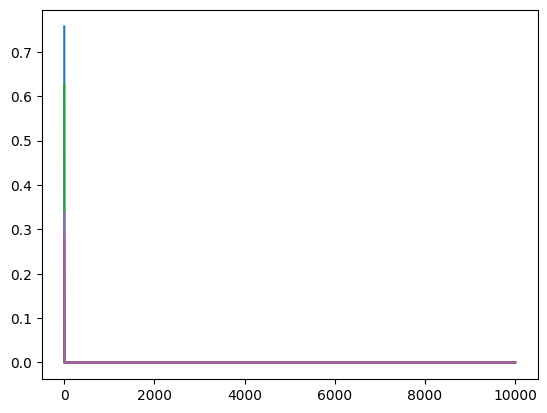

In [41]:
for i in range(5):
    plt.plot(abs(morlet_ifft[i,:]))

In [38]:
complex_fft = fits*np.cos(params[:,:,3]).reshape(params.shape[:2]+(1,))+1j*fits*np.sin(params[:,:,3]).reshape(params.shape[:2]+(1,))
morlet_ifft = np.array([np.fft.ifft(complex_fft[1034,i,:]) for i in range(5)])
morlet_ifft.shape

(5, 10000)

/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


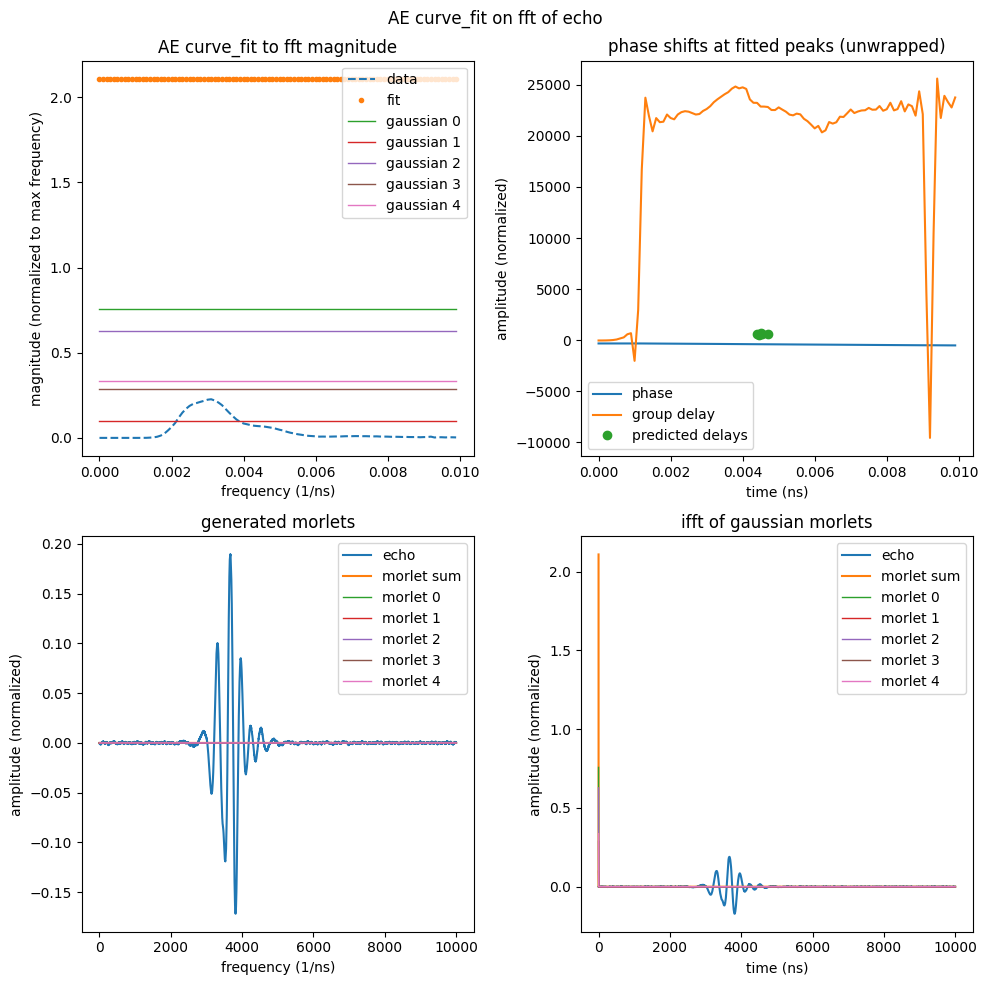

In [46]:
fig, axs = plt.subplots(2,2, figsize=(10, 10))
idx = 1034
freq = torch.fft.fftshift(torch.fft.fftfreq(dset.spec_len)).numpy()

f = freq[len(freq)//2:len(freq)//2+100]
mag = np.abs(dset[idx][1])[len(freq)//2:len(freq)//2+100]
angles = np.unwrap(np.angle(dset[idx][1]))
group_delay = -np.gradient(angles, freq)
t = np.arange(0, dset.spec_len)

morlet_generated = model.encoder.function.generate_fit_(torch.tensor(params[1034]).unsqueeze(0), dset.spec_len)[0]
complex_fft = fits*np.cos(params[:,:,3]).reshape(params.shape[:2]+(1,))+1j*fits*np.sin(params[:,:,3]).reshape(params.shape[:2]+(1,))
morlet_ifft = np.array([np.fft.ifft(complex_fft[1034,i,:]) for i in range(5)])


fig.suptitle('AE curve_fit on fft of echo')

axs[0,0].set_title('AE curve_fit to fft magnitude')
axs[0,0].set_ylabel('magnitude (normalized to max frequency)')
axs[0,0].plot(f, mag, '--', label='data')
axs[0,0].plot(f,fits[idx,:,len(freq)//2:len(freq)//2+100].sum(axis=0), '.', label='fit')
for i in range(5):
    axs[0,0].plot(f, fits[idx,i,len(freq)//2:len(freq)//2+100], 
                    label=f'gaussian {i}', linewidth=1)
axs[0,0].legend()

axs[0,1].set_title('phase shifts at fitted peaks (unwrapped)')
axs[0,1].set_ylabel('phase (rad), group delay (ns)')
axs[0,1].plot(f, angles[len(freq)//2:len(freq)//2+100], label='phase')
axs[0,1].plot(f, group_delay[len(freq)//2:len(freq)//2+100], label='group delay')
axs[0,1].plot(params[idx,:,3], params[idx,:,1], 'o', label='predicted delays')
axs[0,1].legend()

axs[1,0].set_title('generated morlets')
axs[1,0].set_ylabel('amplitude (normalized)')
axs[1,0].plot(t, dset.data[f'processed_{dset.dset_name}'][idx], label='echo')
axs[1,0].plot(t, morlet_generated.sum(axis=0), label='morlet sum')
for i in range(params.shape[1]): 
    axs[1,0].plot(t, morlet_generated[i], linewidth=1, label=f'morlet {i}') 
axs[1,0].legend()

axs[1,1].set_title('ifft of gaussian morlets')
axs[1,1].set_ylabel('amplitude (normalized)')
axs[1,1].plot(t, dset.data[f'processed_{dset.dset_name}'][idx], label='echo')
axs[1,1].plot(t, morlet_ifft.sum(axis=0), label='morlet sum')
for i in range(params.shape[1]): 
    axs[1,1].plot(t, morlet_ifft[i], linewidth=1, label=f'morlet {i}') 
axs[1,1].legend()

for i in range(2):
    axs[i,0].set_xlabel('frequency (1/ns)')
    axs[i,1].set_xlabel('time (ns)')
    axs[i,1].set_ylabel('amplitude (normalized)')

fig.tight_layout()

### uncropped

/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


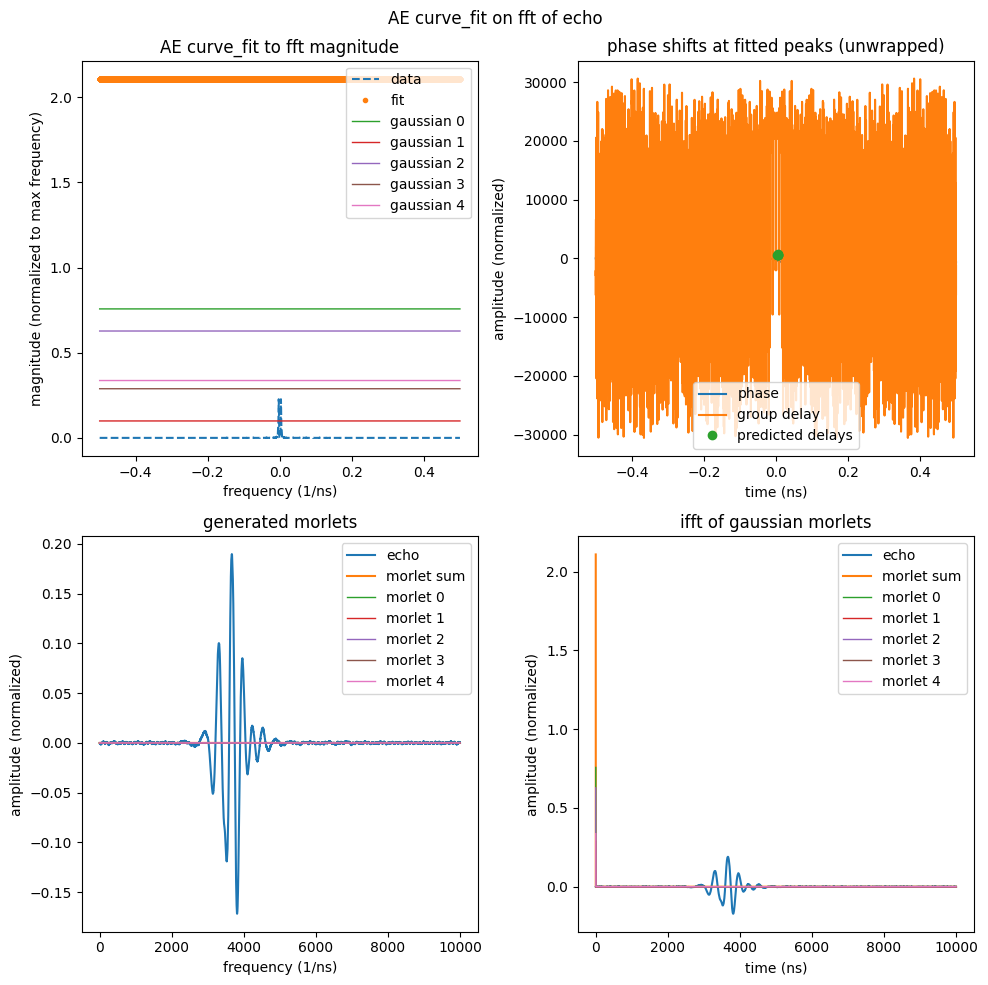

In [48]:
fig, axs = plt.subplots(2,2, figsize=(10, 10))
idx = 1034
freq = torch.fft.fftshift(torch.fft.fftfreq(dset.spec_len)).numpy()

f = freq
mag = np.abs(dset[idx][1])
angles = np.unwrap(np.angle(dset[idx][1]))
group_delay = -np.gradient(angles, freq)
t = np.arange(0, dset.spec_len)

morlet_generated = model.encoder.function.generate_fit_(torch.tensor(params[1034]).unsqueeze(0), dset.spec_len)[0]
complex_fft = fits*np.cos(params[:,:,3]).reshape(params.shape[:2]+(1,))+1j*fits*np.sin(params[:,:,3]).reshape(params.shape[:2]+(1,))
morlet_ifft = np.array([np.fft.ifft(complex_fft[1034,i,:]) for i in range(5)])


fig.suptitle('AE curve_fit on fft of echo')

axs[0,0].set_title('AE curve_fit to fft magnitude')
axs[0,0].set_ylabel('magnitude (normalized to max frequency)')
axs[0,0].plot(f, mag, '--', label='data')
axs[0,0].plot(f,fits[idx,:].sum(axis=0), '.', label='fit')
for i in range(5):
    axs[0,0].plot(f, fits[idx,i], 
                    label=f'gaussian {i}', linewidth=1)
axs[0,0].legend()

axs[0,1].set_title('phase shifts at fitted peaks (unwrapped)')
axs[0,1].set_ylabel('phase (rad), group delay (ns)')
axs[0,1].plot(f, angles, label='phase')
axs[0,1].plot(f, group_delay, label='group delay')
axs[0,1].plot(params[idx,:,3], params[idx,:,1], 'o', label='predicted delays')
axs[0,1].legend()

axs[1,0].set_title('generated morlets')
axs[1,0].set_ylabel('amplitude (normalized)')
axs[1,0].plot(t, dset.data[f'processed_{dset.dset_name}'][idx], label='echo')
axs[1,0].plot(t, morlet_generated.sum(axis=0), label='morlet sum')
for i in range(params.shape[1]): 
    axs[1,0].plot(t, morlet_generated[i], linewidth=1, label=f'morlet {i}') 
axs[1,0].legend()

axs[1,1].set_title('ifft of gaussian morlets')
axs[1,1].set_ylabel('amplitude (normalized)')
axs[1,1].plot(t, dset.data[f'processed_{dset.dset_name}'][idx], label='echo')
axs[1,1].plot(t, morlet_ifft.sum(axis=0), label='morlet sum')
for i in range(params.shape[1]): 
    axs[1,1].plot(t, morlet_ifft[i], linewidth=1, label=f'morlet {i}') 
axs[1,1].legend()

for i in range(2):
    axs[i,0].set_xlabel('frequency (1/ns)')
    axs[i,1].set_xlabel('time (ns)')
    axs[i,1].set_ylabel('amplitude (normalized)')

fig.tight_layout()

In [35]:
from viz.visualize_scan_data import training_viewer
x,z = 6,25
training_viewer(dset, fits, params, idx=x*dset.image_shape[1]+z)
    

TypeError: Object of type complex is not JSON serializable

TypeError: Object of type complex is not JSON serializable

TypeError: Object of type complex is not JSON serializable

Figure({
    'data': [{'mode': 'lines',
              'name': 'original',
              'type': 'scatter',
              'x': [0, 1, 2, ..., 9997, 9998, 9999],
              'xaxis': 'x',
              'y': array([(1.2063232480239206e-05-1.1074634435854027e-19j),
                          (-8.545383409369458e-06-1.4585785150093617e-05j),
                          (1.5115416500346838e-06-1.9065554951666267e-05j), ...,
                          (7.883504349302897e-06+3.2419086019107332e-06j),
                          (1.511541650034562e-06+1.9065554951666263e-05j),
                          (-8.545383409369497e-06+1.4585785150093619e-05j)],
                         shape=(10000,), dtype=object),
              'yaxis': 'y'},
             {'mode': 'lines',
              'name': 'sum',
              'type': 'scatter',
              'x': [0, 1, 2, ..., 9997, 9998, 9999],
              'xaxis': 'x',
              'y': {'bdata': ('AAAA0CUs/j8AAADQJSz+PwAAANAlLP' ... 'DoJSz+PwAAAOglLP4/AAAA6CU